<a href="https://colab.research.google.com/github/camilapereira1304/TCC_UFRPE/blob/main/tcc_melhorias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================
#  1. INSTALAR BIBLIOTECAS
# =========================================
!pip uninstall -y nilearn
!pip install --no-cache-dir nilearn==0.12.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 104.7 MB/s eta 0:00:00


In [ ]:
# =========================================
#  2. IMPORTAR BIBLIOTECAS
# =========================================
import numpy as np                  # operações numéricas
import pandas as pd                # manipulação de dados em tabela

from nilearn import datasets       # baixar datasets e atlas
from nilearn.maskers import NiftiLabelsMasker  # extrair sinais do cérebro
from nilearn.connectome import ConnectivityMeasure # calcular conectividade

from sklearn.model_selection import train_test_split, GridSearchCV # divisão e otimização
from sklearn.pipeline import Pipeline   # criar pipeline (organiza etapas)
from sklearn.preprocessing import StandardScaler # normalização
from sklearn.decomposition import PCA   # redução de dimensionalidade
from sklearn.svm import SVC             # modelo SVM
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [ ]:
# =========================================
#  3. BAIXAR DADOS
# =========================================

# Baixar apenas dados do centro da NYU (Universidade de Nova York) para evitar efeito de sítio
abide = datasets.fetch_abide_pcp(
    pipeline='cpac',
    band_pass_filtering=True,
    global_signal_regression=False,
    derivatives=['func_preproc'],
    SITE_ID=['NYU'] # Filtra apenas exames deste centro específico
)

[fetch_abide_pcp] Added README.md to /root/nilearn_data

[fetch_abide_pcp] Dataset created in /root/nilearn_data/ABIDE_pcp

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Phenotypic_V1_0b_preprocessed1.csv ...

[fetch_abide_pcp]  ...done. (1 seconds, 0 min)

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/filt_noglobal/func_preproc/NYU_005095
2_func_preproc.nii.gz ...

...

[fetch_abide_pcp] Downloaded 14680064 of 103783342 bytes (14.1%%,    6.3s remaining)

[fetch_abide_pcp] Downloaded 40091648 of 103783342 bytes (38.6%%,    3.2s remaining)

[fetch_abide_pcp] Downloaded 66813952 of 103783342 bytes (64.4%%,    1.7s remaining)

[fetch_abide_pcp] Downloaded 94797824 of 103783342 bytes (91.3%%,    0.4s remaining)

[fetch_abide_pcp]  ...done. (5 seconds, 0 min)

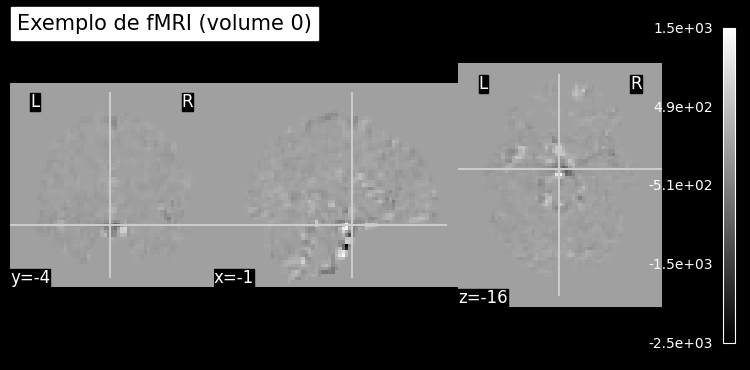

In [ ]:
#Visualizar cérebro
from nilearn import image, plotting

img_4d = image.load_img(abide.func_preproc[0])

# pega o primeiro volume (tempo = 0)
img_3d = image.index_img(img_4d, 0)

plotting.plot_epi(img_3d, title="Exemplo de fMRI (volume 0)")
plotting.show()

/tmp/ipykernel_8383/3410618155.py:6: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_img = image.mean_img(img_4d)


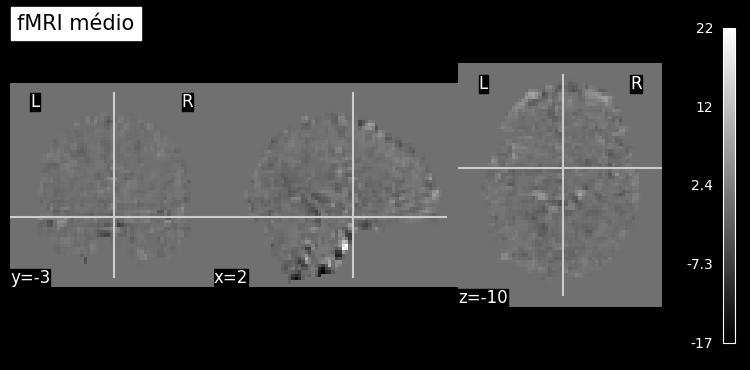

In [ ]:
from nilearn import image, plotting

img_4d = image.load_img(abide.func_preproc[0])

# média ao longo do tempo
mean_img = image.mean_img(img_4d)

plotting.plot_epi(mean_img, title="fMRI médio")
plotting.show()

In [ ]:
#Ver dimensão do fMRI
from nilearn import image

img = image.load_img(abide.func_preproc[0])
print("Dimensão da imagem:", img.shape)

Dimensão da imagem: (61, 73, 61, 176)


In [ ]:
# =========================================
#  4. DADOS FENOTÍPICOS (TABELA)
# =========================================
df = pd.DataFrame(abide.phenotypic)  # transforma em tabela

# cria rótulo: 1 = autismo | 0 = controle
df['label'] = df['DX_GROUP'].apply(lambda x: 1 if x == 1 else 0)

# QUANTIDADE TOTAL DE SUJEITOS
print("Total de sujeitos:", len(df))

# DISTRIBUIÇÃO DAS CLASSES
print(df['label'].value_counts())


Total de sujeitos: 172
label
0    98
1    74
Name: count, dtype: int64


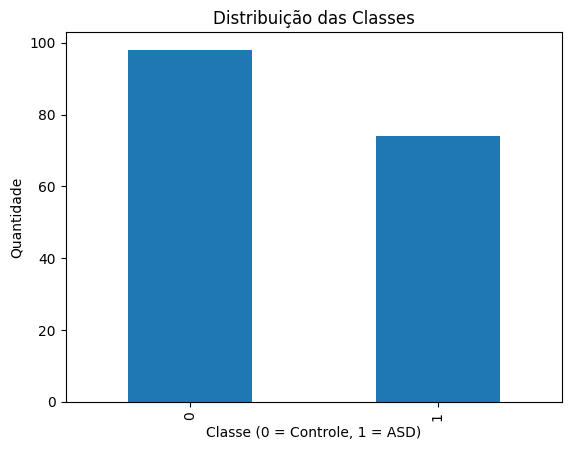

In [ ]:
# =========================================
#  5. Distribuição das classes
# =========================================

import matplotlib.pyplot as plt

counts = df['label'].value_counts()

plt.figure()
counts.plot(kind='bar')

plt.title("Distribuição das Classes")
plt.xlabel("Classe (0 = Controle, 1 = ASD)")
plt.ylabel("Quantidade")

plt.show()

In [ ]:
#verificar dados faltantes
print(df.isnull().sum())

i                          0
Unnamed: 0                 0
SUB_ID                     0
X                          0
subject                    0
                        ... 
qc_anat_notes_rater_3    172
qc_func_rater_3            0
qc_func_notes_rater_3    172
SUB_IN_SMP                 0
label                      0
Length: 107, dtype: int64


In [ ]:
# =========================================
#  6. ATLAS SCHAEFER
# =========================================
#Aumentar o número de ROIs para maior resoluçãoS

atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200)

[fetch_atlas_schaefer_2018] Dataset created in /root/nilearn_data/schaefer_2018

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_200Parcels_7Networks_order.txt ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_200Parcels_7Networks_order_FSLMNI152_1mm.
nii.gz ...

[fetch_atlas_schaefer_2018]  ...done. (1 seconds, 0 min)

In [ ]:
# =========================================
#  7. EXTRAIR SINAIS DO CÉREBRO
# =========================================
import time

inicio = time.time()

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,   # usa o atlas como referência
    standardize=True         # normaliza os sinais
)

time_series = []

# percorre cada exame fMRI
for func_file in abide.func_preproc:
    ts = masker.fit_transform(func_file)  # extrai sinais por região
    time_series.append(ts)                # guarda resultado

fim = time.time()

print("Tempo:", (fim-inicio)/60, "minutos")

Tempo: 58.24914476076762 minutos


In [ ]:
# =========================================
#  8. CALCULAR CONECTIVIDADE FUNCIONAL
# =========================================
connectivity = ConnectivityMeasure(kind='correlation')

conn_matrices = connectivity.fit_transform(time_series)

In [ ]:
# =========================================
#  9. TRANSFORMAR MATRIZ EM VETOR (ML)
# =========================================
def flatten_matrix(mat):
    return mat[np.triu_indices_from(mat, k=1)]  # pega metade da matriz

# cria matriz de features (X)
X = np.array([flatten_matrix(m) for m in conn_matrices])

# cria vetor de rótulos (y)
y = df['label'].values


# Conferir shapes
print("Shape X:", X.shape)
print("Shape y:", y.shape)

#Estatísticas
print("Média:", X.mean())
print("Desvio padrão:", X.std())

Shape X: (172, 19900)
Shape y: (172,)
Média: 0.20919251320078053
Desvio padrão: 0.22238338733244242


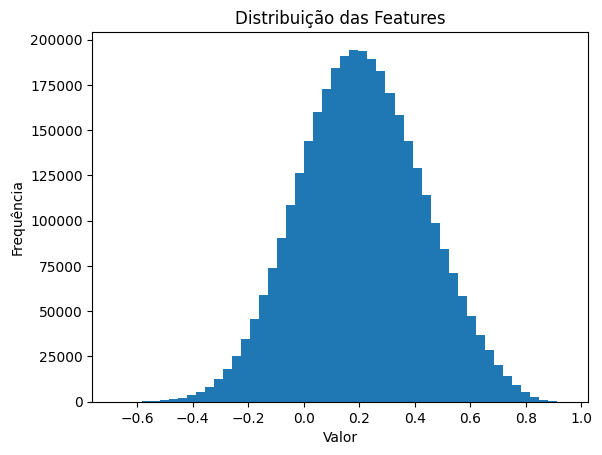

In [ ]:
#Histograma
plt.figure()
plt.hist(X.flatten(), bins=50)

plt.title("Distribuição das Features")
plt.xlabel("Valor")
plt.ylabel("Frequência")

plt.show()

In [ ]:
# =========================================
# 10. DIVIDIR DADOS (TREINO / TESTE)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% teste
    random_state=42,     # reprodutibilidade
    stratify=y           # mantém proporção das classes
)

In [ ]:
# =========================================
# 11. VALIDAÇÃO CRUZADA SOMENTE NO TREINO
# =========================================
from sklearn.model_selection import cross_val_score

pipe_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(
        n_components=30,
        svd_solver='randomized',
        random_state=42
    )),
    ('svm', SVC(
        C=1,
        kernel='rbf',
        class_weight='balanced'
    ))
])

scores = cross_val_score(
    pipe_cv,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1
)

print("Scores por fold:", scores)
print("Acurácia média (CV - treino):", scores.mean())
print("Desvio padrão:", scores.std())

Scores por fold: [0.64285714 0.57142857 0.55555556 0.62962963 0.55555556]
Acurácia média (CV - treino): 0.591005291005291
Desvio padrão: 0.03762198695160039


In [ ]:
# =========================================
#  12. PIPELINE COMPLETO (SCALER + PCA + SVM)
# =========================================
pipe = Pipeline([
    ('scaler', StandardScaler()),  # normaliza os dados
    ('pca', PCA( # reduz dimensionalidade
        svd_solver='randomized',
        random_state=42
    )),
    ('svm', SVC())                 # modelo de classificação
])

In [ ]:
# =========================================
# 13. GRIDSEARCH (OTIMIZAÇÃO)
# =========================================
param_grid = {
    'pca__n_components': [30, 50, 80, 100],   # quantas features manter
    'svm__C': [0.001, 0.01, 0.1, 1, 10],               # regularização
    'svm__kernel': ['linear', 'rbf'],     # tipo de SVM
    'svm__gamma': ['scale', 'auto'],
    'svm__class_weight': ['balanced']     # balanceamento das classes
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,             # validação cruzada interna
    n_jobs=-1         # usa todos os núcleos disponíveis
)

# treina todos os modelos
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)

Melhores parâmetros: {'pca__n_components': 100, 'svm__C': 0.001, 'svm__class_weight': 'balanced', 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


In [ ]:
# =========================================
# 14. USAR MELHOR MODELO
# =========================================
best_model = grid.best_estimator_

In [ ]:
# =========================================
#  15. FAZER PREVISÕES
# =========================================
y_pred = best_model.predict(X_test)

In [ ]:
# =========================================
# 16. AVALIAÇÃO DO MODELO
# =========================================
print("Acurácia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Acurácia: 0.6
              precision    recall  f1-score   support

           0       0.64      0.70      0.67        20
           1       0.54      0.47      0.50        15

    accuracy                           0.60        35
   macro avg       0.59      0.58      0.58        35
weighted avg       0.59      0.60      0.60        35



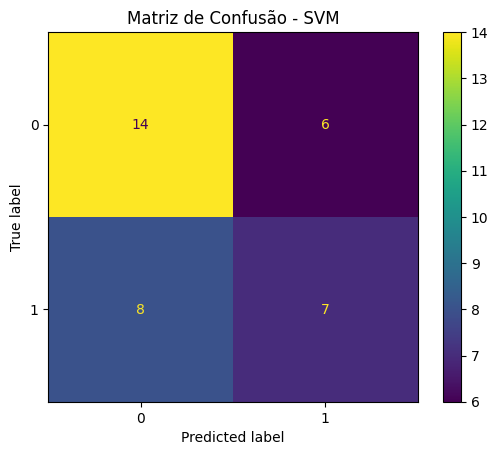

In [ ]:
#MATRIZ CONFUSÃO
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matriz de Confusão - SVM")
plt.show()

In [ ]:
# =========================================
#  17. AUC (MÉTRICA AVANÇADA)
# =========================================
y_prob = best_model.decision_function(X_test)

print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.64


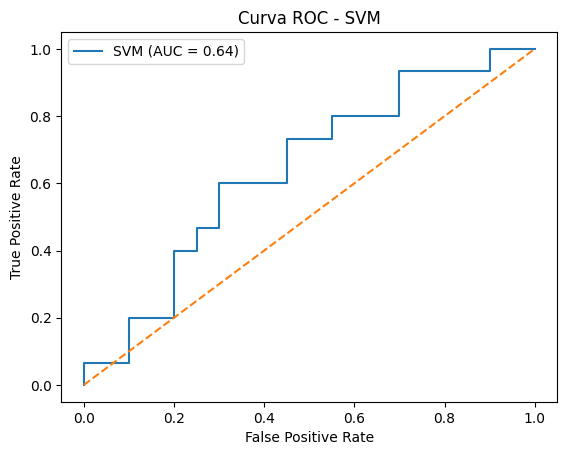

In [ ]:
# CURVA ROC (SVM)
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - SVM")
plt.legend()

plt.show()

In [ ]:
# =========================================
#  18. RANDOM FOREST (COMPARAÇÃO)
# =========================================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Acurácia RF:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Acurácia RF: 0.7428571428571429
              precision    recall  f1-score   support

           0       0.72      0.90      0.80        20
           1       0.80      0.53      0.64        15

    accuracy                           0.74        35
   macro avg       0.76      0.72      0.72        35
weighted avg       0.75      0.74      0.73        35



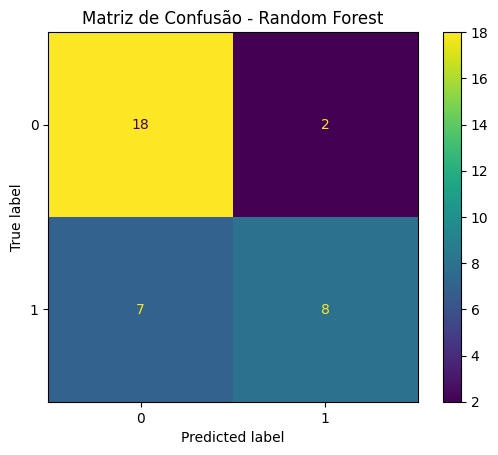

In [ ]:
#MATRIZ DE CONFUSÃO (RF)
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()

plt.title("Matriz de Confusão - Random Forest")
plt.show()

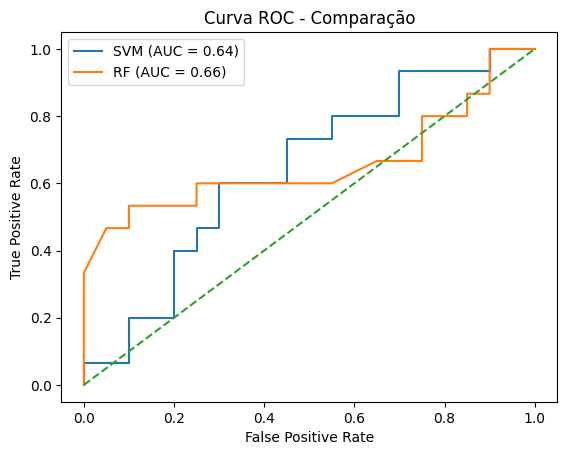

AUC RF: 0.6566666666666665


In [ ]:
#ROC COMPARANDO SVM vs RF

# =========================================
#  CURVA ROC (COMPARAÇÃO)
# =========================================

# Probabilidade RF
y_prob_rf = rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()

plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {roc_auc_rf:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparação")
plt.legend()

plt.show()
print("AUC RF:", roc_auc_rf)

In [ ]:
# =========================================
# 19. INTELIGÊNCIA ARTIFICIAL EXPLICÁVEL (XAI) - DINÂMICO
# Mapeamento de Regiões Cerebrais Relevantes
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# 1. Extrair as importâncias calculadas pelo Random Forest
importances = rf.feature_importances_

# 2. Obter os nomes das regiões e o número de ROIs DINAMICAMENTE do atlas carregado
roi_names = [label.decode('utf-8') if isinstance(label, bytes) else str(label) for label in atlas.labels]
n_rois = len(roi_names)

# 3. Obter os índices originais da matriz de conectividade para este número real de ROIs
row_idx, col_idx = np.triu_indices(n_rois, k=1)
num_connections = len(row_idx)

print(f"✔ [LOG] Número de ROIs detectadas no atlas: {n_rois}")
print(f"✔ [LOG] Número de conexões cerebrais esperadas: {num_connections}")
print(f"✔ [LOG] Número total de features encontradas no Random Forest: {len(importances)}")

# 4. Associar cada valor de importância ao seu par de regiões (apenas para as conexões cerebrais)
connections_data = []

# O min() garante que o loop só vai até o limite real das conexões anatômicas
for i in range(min(len(importances), num_connections)):
    reg1 = roi_names[row_idx[i]]
    reg2 = roi_names[col_idx[i]]
    connections_data.append({
        'Regiao_1': reg1,
        'Regiao_2': reg2,
        'Importancia': importances[i]
    })

# Criar DataFrame das conexões e ordenar pelas mais importantes
df_connections = pd.DataFrame(connections_data)
df_connections = df_connections.sort_values(by='Importancia', ascending=False)

print("\n--- TOP 10 CONEXÕES MAIS IMPORTANTES PARA O MODELO ---")
print(df_connections.head(10))
print("\n" + "="*50 + "\n")

# 5. Calcular a importância ACUMULADA por região isolada
region_importances = {}
for roi in roi_names:
    total_imp = df_connections[(df_connections['Regiao_1'] == roi) | (df_connections['Regiao_2'] == roi)]['Importancia'].sum()
    region_importances[roi] = total_imp

# Criar DataFrame das regiões isoladas
df_regions = pd.DataFrame(list(region_importances.items()), columns=['Regiao', 'Importancia_Acumulada'])
df_regions = df_regions.sort_values(by='Importancia_Acumulada', ascending=False)

print("--- TOP 10 REGIÕES CEREBRAIS MAIS RELEVANTES GERAL ---")
print(df_regions.head(10))

# 6. Se houverem variáveis fenotípicas extras no final, mostra a importância delas isoladamente
if len(importances) > num_connections:
    print("\n" + "="*50 + "\n")
    print("--- IMPORTÂNCIA DE CARACTERÍSTICAS EXTRA (FENOTÍPICAS) ---")
    extra_features = importances[num_connections:]
    for idx, imp in enumerate(extra_features):
        print(f"Variável Extra {idx+1}: Importância = {imp:.6f}")

✔ [LOG] Número de ROIs detectadas no atlas: 201
✔ [LOG] Número de conexões cerebrais esperadas: 20100
✔ [LOG] Número total de features encontradas no Random Forest: 19900

--- TOP 10 CONEXÕES MAIS IMPORTANTES PARA O MODELO ---
                             Regiao_1                               Regiao_2  \
10676         7Networks_LH_Cont_Par_3            7Networks_LH_Default_PFC_11   
11605        7Networks_LH_Cont_PFCl_5             7Networks_LH_Default_PFC_9   
3901            7Networks_LH_SomMot_6                    7Networks_RH_Vis_12   
9483   7Networks_LH_SalVentAttn_Med_3               7Networks_RH_Cont_PFCv_1   
14734  7Networks_LH_Default_pCunPCC_1        7Networks_RH_Default_PFCdPFCm_1   
4648           7Networks_LH_SomMot_10  7Networks_RH_SalVentAttn_TempOccPar_2   
1391               7Networks_LH_Vis_7                  7Networks_LH_SomMot_6   
2761              7Networks_LH_Vis_14               7Networks_LH_Cont_PFCl_2   
9565        7Networks_LH_Limbic_OFC_1                

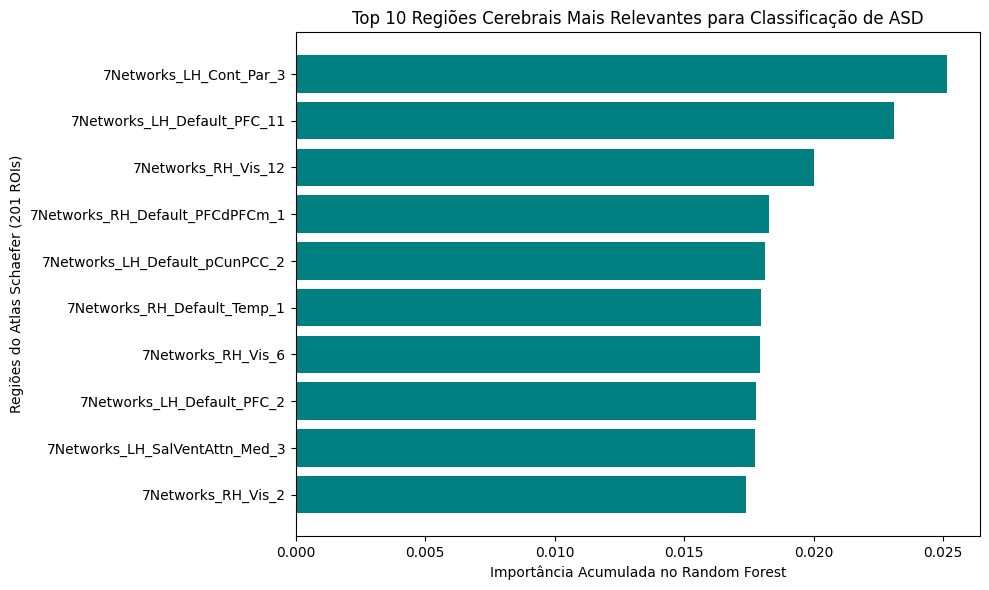

In [ ]:
# =========================================
# 20. GERAR GRÁFICO PARA O TEXTO DO TCC
# =========================================
plt.figure(figsize=(10, 6))
top_10_regions = df_regions.head(10)

plt.barh(top_10_regions['Regiao'][::-1], top_10_regions['Importancia_Acumulada'][::-1], color='teal')
plt.xlabel('Importância Acumulada no Random Forest')
plt.ylabel(f'Regiões do Atlas Schaefer ({n_rois} ROIs)')
plt.title('Top 10 Regiões Cerebrais Mais Relevantes para Classificação de ASD')
plt.tight_layout()
plt.show()

In [ ]:
import sys
print(sys.version)

In [ ]:
!lscpu | head -20
!free -h
!nvidia-smi

In [ ]:
import platform

print(platform.system())
print(platform.platform())

In [ ]:
import time

inicio = time.time()

# código

fim = time.time()

print("Tempo:", fim - inicio)